# Analyse électorale IRIS — France

Trois axes :
1. **Variables déterminantes** — quelles variables socio expliquent le vote pour chaque parti ?
2. **Proximité entre partis** — structure de l'espace partisan, distances, clusters
3. **Report de voix** — flux entre tours et entre élections

Données : 49 140 IRIS × 23 scrutins (2012–2026), variables socio-démographiques INSEE.

**Toutes les régressions sont pondérées par le nombre d'exprimés** (WLS).
Les variables socio sont normalisées via Robust Scaling (médiane/IQR) avant toute analyse multivariée.


## Section 0 — Setup & Preprocessing


In [1]:
import sys, os, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes as scipy_procrustes
from scipy.stats import wasserstein_distance

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.feature_selection import mutual_info_regression

import statsmodels.api as sm
from statsmodels.sandbox.sysreg import SUR

import xgboost as xgb
import shap
import networkx as nx
import umap.umap_ as umap_lib

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from shared_config import ELECTIONS_AVAILABLE, COULEURS, LABELS

print('Packages OK.')
print(f'Elections disponibles : {len(ELECTIONS_AVAILABLE)}')


Packages OK.
Elections disponibles : 23


In [63]:
# ── Chargement des données ────────────────────────────────────────────────────
SOCIO_PATH     = 'iris/iris_final_socio_politique.csv'
ELECTIONS_DIR  = 'iris/elections'

print('Chargement du fichier socio...')
socio_raw = pd.read_csv(SOCIO_PATH, dtype={'IRIS': str, 'COM': str}, low_memory=False)
print(f'  socio_raw : {socio_raw.shape}')

print('Chargement des élections...')
elections_raw = {}
for elec_id in ELECTIONS_AVAILABLE:
    path = f'{ELECTIONS_DIR}/{elec_id}.csv'
    if os.path.exists(path):
        elections_raw[elec_id] = pd.read_csv(path, dtype={'CODE_IRIS': str})
        elections_raw[elec_id]['score_ABST'] = elections_raw[elec_id]['pct_abstention']
print(f'  {len(elections_raw)} fichiers électoraux chargés.')


Chargement du fichier socio...
  socio_raw : (49140, 512)
Chargement des élections...
  23 fichiers électoraux chargés.


In [64]:
# ── Groupes de variables ─────────────────────────────────────────────────────
SCORES_COMPOSITES = [
    'score_domination', 'score_exploitation', 'score_cap_eco', 'score_cap_cult',
    'score_precarite', 'score_rentier', 'score_urbanite',
    'score_confort_residentiel', 'score_equipement_public', 'score_dependance_carbone'
]

SCORES_PCA = [f'score_pca_{i}' for i in range(1, 9)]

_VARS_BRUTES_CANDIDATS = [
    'pct_chomage', 'pct_sup5', 'pct_sans_diplome', 'pct_bac_plus',
    'pct_hlm', 'pct_proprietaires', 'pct_locataires',
    'pct_csp_ouvrier', 'pct_csp_plus', 'pct_csp_intermediaire',
    'pct_csp_employe', 'pct_csp_retraite', 'pct_csp_sans_emploi',
    'pct_etrangers', 'pct_immigres',
    'DISP_MED21', 'DISP_GI21',
    'pct_actifs_voiture', 'pct_actifs_transports', 'pct_actifs_velo',
    'pct_logements_recents', 'pct_maison', 'pct_appart', 'pct_voiture_0',
    'age_moyen', 'taille_menage_moy',
    'bpe_sante_pour1000', 'bpe_enseignement_pour1000',
]
VARS_BRUTES = [v for v in _VARS_BRUTES_CANDIDATS if v in socio_raw.columns]

ALL_VARS = SCORES_COMPOSITES + SCORES_PCA + VARS_BRUTES
ALL_VARS = [v for v in ALL_VARS if v in socio_raw.columns]

print(f'Scores composites : {len(SCORES_COMPOSITES)}')
print(f'Scores PCA        : {len(SCORES_PCA)}')
print(f'Variables brutes  : {len(VARS_BRUTES)}')


Scores composites : 10
Scores PCA        : 8
Variables brutes  : 26


In [65]:
# ── Normalisation robuste ─────────────────────────────────────────────────────
socio = socio_raw.copy()

# Imputer les NaN par la médiane de la colonne avant scaling
cols_to_scale = [c for c in ALL_VARS if c in socio.columns]
medians = socio[cols_to_scale].median()
socio[cols_to_scale] = socio[cols_to_scale].fillna(medians)

scaler = RobustScaler()
socio_scaled_values = scaler.fit_transform(socio[cols_to_scale])

socio_scaled = socio.copy()
socio_scaled[cols_to_scale] = socio_scaled_values

print('Normalisation robuste appliquée sur', len(cols_to_scale), 'colonnes.')


Normalisation robuste appliquée sur 44 colonnes.


In [66]:
# ── Segmentation urbain / périurbain / rural ──────────────────────────────────
# Via tertiles de score_urbanite (valeurs brutes, pas scalées)
if 'score_urbanite' in socio.columns:
    tertile_labels = ['Rural', 'Périurbain', 'Urbain']
    socio['segment'] = pd.qcut(
        socio['score_urbanite'],
        q=3, labels=tertile_labels, duplicates='drop'
    )
    socio_scaled['segment'] = socio['segment']
    print('Segmentation créée :')
    print(socio['segment'].value_counts())


Segmentation créée :
segment
Rural         16380
Périurbain    16380
Urbain        16380
Name: count, dtype: int64


In [67]:
# ── Table de correspondance des partis entre élections ───────────────────────
# Permet de comparer législatives 2017/2022/2024 et présidentielles entre elles
PARTY_ALIAS = {
    # Candidats présidentiels → étiquette de parti
    'MACRON': 'ENS', 'FILLON': 'LR', 'MELENCHON': 'LFI',
    'HAMON': 'PS', 'LE_PEN': 'RN', 'DUPONT_AIGNAN': 'DLF',
    'PECRESSE': 'LR', 'ZEMMOUR': 'REC', 'JADOT': 'EELV',
    'ROUSSEL': 'PCF', 'HIDALGO': 'PS',
    'HOLLANDE': 'PS', 'SARKOZY': 'LR', 'BAYROU': 'MODEM', 'JOLY': 'EELV',
    # Coalitions changeantes
    'NUPES': 'NFP', 'FN': 'RN', 'PS_PP': 'PS', 'LREM': 'ENS',
    # Partis stables (identité)
    'RN': 'RN', 'ENS': 'ENS', 'LFI': 'LFI', 'PS': 'PS',
    'LR': 'LR', 'EELV': 'EELV', 'PCF': 'PCF', 'REC': 'REC',
    'DLF': 'DLF', 'NFP': 'NFP', 'DVD': 'DVD', 'DVG': 'DVG',
    'DVC': 'DVC', 'EXG': 'EXG', 'EXD': 'EXD',
    'MODEM': 'MODEM', 'UDI': 'UDI', 'HOR': 'HOR', 'REG': 'REG',
    'UG': 'UG', 'UXD': 'UXD',
    'ABST': 'ABST',
}


In [68]:
# ── Fonctions utilitaires ─────────────────────────────────────────────────────

def get_parties(elec_id):
    """Liste des partis/candidats d'une élection (colonnes score_*)."""
    df = elections_raw[elec_id]
    score_cols = [c for c in df.columns
                  if c.startswith('score_') and c not in ('score_blanc', 'score_nul')]
    return [c.replace('score_', '') for c in score_cols]


def get_elec_df(elec_id, min_presence_frac=0.20, use_scaled=True):
    """
    Fusionne les données socio avec une élection.
    Retourne (DataFrame fusionné, liste des partis valides).
    min_presence_frac : fraction minimale d'IRIS où le parti dépasse 1% pour être inclus.
    """
    base = socio_scaled if use_scaled else socio
    elec = elections_raw[elec_id].copy().rename(columns={'CODE_IRIS': 'IRIS'})
    merged = base.merge(elec, on='IRIS', how='inner')

    # Poids WLS = nb d'exprimés, normalisé
    if 'exprimes' in merged.columns:
        merged['_w'] = merged['exprimes'].fillna(1)
    elif 'pop_totale' in merged.columns:
        merged['_w'] = merged['pop_totale'].fillna(1)
    else:
        merged['_w'] = 1.0
    merged['_w'] = merged['_w'] / merged['_w'].mean()

    # Filtrage partis par présence
    parties = get_parties(elec_id)
    valid_parties = []
    for p in parties:
        sc = f'score_{p}'
        if sc in merged.columns:
            pres = (merged[sc].fillna(0) > 1.0).mean()
            if pres >= min_presence_frac:
                valid_parties.append(p)
    return merged, valid_parties


def weighted_corr(x, y, w):
    """Corrélation de Pearson pondérée."""
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    if mask.sum() < 5:
        return np.nan
    x, y, w = x[mask], y[mask], w[mask]
    w = w / w.sum()
    mx, my = np.dot(w, x), np.dot(w, y)
    cov = np.dot(w, (x - mx) * (y - my))
    sx  = np.sqrt(np.dot(w, (x - mx)**2))
    sy  = np.sqrt(np.dot(w, (y - my)**2))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan


def barycentre(merged, party, vars_list):
    """Barycentre sociologique d'un parti : moyenne pondérée par score×pop."""
    y = merged[f'score_{party}'].fillna(0).values / 100.0
    w = y * merged['_w'].values
    total = w.sum()
    if total <= 0:
        return {v: np.nan for v in vars_list}
    return {v: np.dot(w, merged[v].fillna(0).values) / total for v in vars_list}


def party_color(p):
    return COULEURS.get(p, COULEURS.get(PARTY_ALIAS.get(p, ''), '#9CA3AF'))


def party_label(p):
    return LABELS.get(p, LABELS.get(PARTY_ALIAS.get(p, ''), p))


print('Fonctions utilitaires définies.')


Fonctions utilitaires définies.


In [69]:
elections_raw[list(elections_raw.keys())[0]].keys()

Index(['CODE_IRIS', 'inscrits', 'votants', 'abstentions', 'blancs', 'nuls',
       'exprimes', 'RN', 'REC', 'LR', 'DVD', 'DVC', 'ENS', 'UDI', 'NUPES',
       'DVG', 'EELV', 'REG', 'AUTRE', 'score_RN', 'score_REC', 'score_LR',
       'score_DVD', 'score_DVC', 'score_ENS', 'score_UDI', 'score_NUPES',
       'score_DVG', 'score_EELV', 'score_REG', 'score_AUTRE', 'pct_abstention',
       'score_blanc', 'score_nul', 'score_ABST'],
      dtype='str')

---
## Section 1 — Variables déterminantes par parti

Quel profil sociologique d'IRIS est associé à un score élevé pour chaque parti ?

**Méthodes** :
- 1.1 Corrélations Pearson pondérées (WLS)
- 1.2 Corrélations partielles
- 1.3 Régression LASSO/Ridge WLS
- 1.4 Mutual Information (sklearn)
- 1.5 XGBoost + SHAP
- 1.6 PCA biplot
- 1.7 GWR *(nécessite coordonnées géographiques)*
- 1.8 Analyse par segment urbain/périurbain/rural


In [70]:
# ── Choix de l'élection (modifier ici) ───────────────────────────────────────
ELEC_S1 = '2022_pres_t1'   # ex : '2022_pres_t1', '2024_legi_t1', '2022_legi_t1'
VARS_S1 = SCORES_COMPOSITES  # ou VARS_BRUTES pour analyse plus granulaire

merged_s1, parties_s1 = get_elec_df(ELEC_S1)
print(f'Election : {ELEC_S1}')
print(f'IRIS     : {len(merged_s1)}')
print(f'Partis   : {parties_s1}')


Election : 2022_pres_t1
IRIS     : 48839
Partis   : ['AUTRE', 'DUPONT_AIGNAN', 'HIDALGO', 'JADOT', 'LE_PEN', 'MACRON', 'MELENCHON', 'PECRESSE', 'ROUSSEL', 'ZEMMOUR', 'ABST']


### 1.1 Corrélations Pearson pondérées (WLS)


In [71]:
w = merged_s1['_w'].values

corr_mat = pd.DataFrame(index=VARS_S1, columns=parties_s1, dtype=float)
for party in parties_s1:
    y = merged_s1[f'score_{party}'].values
    for var in VARS_S1:
        corr_mat.loc[var, party] = weighted_corr(merged_s1[var].values, y, w)

# Trier les variables par corrélation absolue maximale
corr_mat_f = corr_mat.astype(float)
row_order = corr_mat_f.abs().max(axis=1).sort_values(ascending=False).index
corr_mat_f = corr_mat_f.loc[row_order]

# Noms lisibles
col_labels = [party_label(p) for p in parties_s1]

fig = go.Figure(go.Heatmap(
    z=corr_mat_f.values,
    x=col_labels,
    y=list(corr_mat_f.index),
    colorscale='RdBu',
    zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title='r'),
    hovertemplate='%{y} × %{x} : %{z:.3f}<extra></extra>'
))
fig.update_layout(
    title=f'Corrélations Pearson pondérées — {ELEC_S1}',
    height=max(400, len(VARS_S1) * 28),
    margin=dict(l=180, b=100)
)
fig.show()


### 1.2 Corrélations partielles pondérées

Corrélation entre variable X et score du parti, en contrôlant pour le revenu médian, le chômage et le % de diplômés supérieurs.


In [72]:
# Confounders à contrôler
CONFOUNDERS = [v for v in ['score_cap_eco', 'score_precarite', 'score_cap_cult']
               if v in merged_s1.columns]


def partial_weighted_corr(x, y, controls, weights):
    """Corrélation partielle pondérée : corrélation des résidus de x et y après régression sur controls."""
    mask = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(controls), axis=1) & np.isfinite(weights)
    if mask.sum() < 20:
        return np.nan
    x_, y_, C, w_ = x[mask], y[mask], controls[mask], weights[mask]
    w_ = w_ / w_.sum()

    def resid(v, C, w):
        C_w = C * np.sqrt(w[:, None])
        v_w = v * np.sqrt(w)
        coef, *_ = np.linalg.lstsq(C_w, v_w, rcond=None)
        return v - C @ coef

    Cfull = np.column_stack([np.ones(len(x_)), C])
    return weighted_corr(resid(x_, Cfull, w_), resid(y_, Cfull, w_), w_)


C = merged_s1[CONFOUNDERS].fillna(0).values
partial_mat = pd.DataFrame(index=VARS_S1, columns=parties_s1, dtype=float)
for party in parties_s1:
    y = merged_s1[f'score_{party}'].values
    for var in VARS_S1:
        if var in CONFOUNDERS:
            # Pas de partial corr d'un confounder avec lui-même
            other_C = np.column_stack([merged_s1[c].fillna(0).values for c in CONFOUNDERS if c != var])
            partial_mat.loc[var, party] = partial_weighted_corr(
                merged_s1[var].values, y, other_C, w)
        else:
            partial_mat.loc[var, party] = partial_weighted_corr(
                merged_s1[var].values, y, C, w)

partial_mat_f = partial_mat.astype(float).loc[row_order]

# Comparaison brute vs partielle côte à côte
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Corrélation brute', 'Corrélation partielle (ctrl : cap_eco, précarité, cap_cult)'])
for col_idx, mat in enumerate([corr_mat_f, partial_mat_f], 1):
    fig.add_trace(go.Heatmap(
        z=mat.values, x=col_labels, y=list(mat.index),
        colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
        showscale=(col_idx == 2),
        hovertemplate='%{y} × %{x} : %{z:.3f}<extra></extra>'
    ), row=1, col=col_idx)

fig.update_layout(title=f'Corrélations brutes vs partielles — {ELEC_S1}',
                  height=max(400, len(VARS_S1) * 28))
fig.show()


### 1.3 Régression LASSO pondérée (WLS)

Coefficients standardisés après régularisation L1 — seules les variables vraiment discriminantes ressortent.


In [73]:
X_lasso = merged_s1[VARS_S1].fillna(0).values
w_lasso = merged_s1['_w'].values

lasso_coefs = {}
for party in parties_s1:
    y = merged_s1[f'score_{party}'].fillna(0).values
    model = LassoCV(cv=5, max_iter=10000, random_state=42, n_alphas=50)
    model.fit(X_lasso, y, sample_weight=w_lasso)
    lasso_coefs[party] = dict(zip(VARS_S1, model.coef_))

lasso_df = pd.DataFrame(lasso_coefs).rename(columns={p: party_label(p) for p in parties_s1})

# Trier par norme L1
row_order_lasso = lasso_df.abs().max(axis=1).sort_values(ascending=False).index
lasso_df = lasso_df.loc[row_order_lasso]

# Filtrer les variables avec tous les coefs à 0
lasso_df = lasso_df.loc[(lasso_df.abs() > 0.001).any(axis=1)]

fig = go.Figure(go.Heatmap(
    z=lasso_df.values,
    x=list(lasso_df.columns),
    y=list(lasso_df.index),
    colorscale='RdBu', zmid=0,
    colorbar=dict(title='coef'),
    hovertemplate='%{y} × %{x} : %{z:.4f}<extra></extra>'
))
fig.update_layout(
    title=f'Coefficients LASSO WLS — {ELEC_S1}',
    height=max(400, len(lasso_df) * 28),
    margin=dict(l=200, b=100)
)
fig.show()


### 1.4 Mutual Information (associations non-linéaires)

Complément à Pearson : capte les relations non-monotones entre variables socio et vote.


In [74]:
X_mi = merged_s1[VARS_S1].fillna(0).values
# Note : mutual_info_regression (sklearn 1.8) n'a pas de paramètre sample_weight
mi_scores = {}
for party in parties_s1:
    y = merged_s1[f'score_{party}'].fillna(0).values
    mi = mutual_info_regression(X_mi, y, random_state=42)
    mi_scores[party] = dict(zip(VARS_S1, mi))

mi_df = pd.DataFrame(mi_scores).rename(columns={p: party_label(p) for p in parties_s1})

# Scatter MI vs |Pearson| — hauts/gauches = effets non-linéaires
fig = make_subplots(rows=1, cols=len(parties_s1),
                    subplot_titles=[party_label(p) for p in parties_s1],
                    shared_yaxes=True)
for i, party in enumerate(parties_s1, 1):
    pearson_abs = corr_mat_f[party].abs()
    mi_vals     = mi_df[party_label(party)]
    vars_common = mi_df.index.intersection(pearson_abs.index)
    fig.add_trace(go.Scatter(
        x=pearson_abs.loc[vars_common].values,
        y=mi_vals.loc[vars_common].values,
        mode='markers+text', text=list(vars_common),
        textposition='top center', textfont=dict(size=8),
        marker=dict(color=party_color(party), size=7),
        showlegend=False,
        hovertemplate='%{text}<br>|Pearson|=%{x:.3f}, MI=%{y:.4f}<extra></extra>'
    ), row=1, col=i)
fig.update_xaxes(title_text='|Pearson|')
fig.update_yaxes(title_text='MI', row=1, col=1)
fig.update_layout(title=f'MI vs |Pearson| — {ELEC_S1}',
                  height=450, width=300 * len(parties_s1))
fig.show()


### 1.5 XGBoost + SHAP

Feature importance juste même en présence de variables colinéaires.


In [17]:
X_shap = merged_s1[VARS_S1].fillna(0)
w_shap = merged_s1['_w'].values

shap_results = {}
for party in parties_s1:
    y = merged_s1[f'score_{party}'].fillna(0).values
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    model.fit(X_shap, y, sample_weight=w_shap)
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_shap)
    shap_results[party] = {
        'mean_abs': pd.Series(np.abs(sv).mean(axis=0), index=VARS_S1),
        'shap_values': sv
    }
    print(f'  SHAP OK — {party_label(party)}')

# Heatmap des SHAP mean|abs| normalisées par parti
shap_df = pd.DataFrame({party_label(p): shap_results[p]['mean_abs'] for p in parties_s1})
shap_df_norm = shap_df.div(shap_df.max())  # normaliser pour comparer entre partis
shap_order = shap_df.max(axis=1).sort_values(ascending=False).index

fig = go.Figure(go.Heatmap(
    z=shap_df_norm.loc[shap_order].values,
    x=list(shap_df.columns),
    y=list(shap_order),
    colorscale='Blues', zmin=0, zmax=1,
    colorbar=dict(title='importance normalisée'),
    hovertemplate='%{y} × %{x} : %{z:.3f}<extra></extra>'
))
fig.update_layout(
    title=f'SHAP feature importance (XGBoost) — {ELEC_S1}',
    height=max(400, len(VARS_S1) * 28),
    margin=dict(l=200, b=100)
)
fig.show()


  SHAP OK — Autres partis
  SHAP OK — Nicolas Dupont-Aignan
  SHAP OK — Anne Hidalgo
  SHAP OK — Yannick Jadot
  SHAP OK — Marine Le Pen
  SHAP OK — Emmanuel Macron
  SHAP OK — Jean-Luc Mélenchon
  SHAP OK — Valérie Pécresse
  SHAP OK — Fabien Roussel
  SHAP OK — Éric Zemmour


### 1.6 PCA biplot

ACP sur les variables socio (après normalisation). Les partis sont projetés comme variables supplémentaires.


In [75]:
X_pca = merged_s1[VARS_S1].fillna(0).values
w_pca = merged_s1['_w'].values

# ACP pondérée : pondérer les observations avant de fitter
X_w = X_pca * np.sqrt(w_pca[:, None])
pca = PCA(n_components=min(6, len(VARS_S1)))
pca.fit(X_w)
coords_iris = pca.transform(X_pca)  # projection sans repondération

exp_var = pca.explained_variance_ratio_
print(f'PC1={exp_var[0]:.1%}  PC2={exp_var[1]:.1%}  PC3={exp_var[2]:.1%}')

# Projeter les partis : corrélation entre scores de vote et chaque PC
party_proj = {}
for party in parties_s1:
    y = merged_s1[f'score_{party}'].fillna(0).values
    y_std = (y - y.mean()) / (y.std() + 1e-10)
    corrs = [weighted_corr(coords_iris[:, pc], y_std, w_pca) for pc in range(2)]
    party_proj[party] = corrs

# ── Figure biplot ─────────────────────────────────────────────────────────────
fig = go.Figure()

# Flèches des variables socio (loadings)
loadings = pca.components_[:2].T  # shape (n_vars, 2)
scale = 3.0  # facteur d'échelle pour la lisibilité
for i, var in enumerate(VARS_S1):
    lx, ly = loadings[i, 0] * scale, loadings[i, 1] * scale
    fig.add_annotation(x=lx, y=ly, ax=0, ay=0,
                        xref='x', yref='y', axref='x', ayref='y',
                        arrowhead=2, arrowwidth=1.5, arrowcolor='#94A3B8',
                        text=var, font=dict(size=9, color='#475569'),
                        showarrow=True)

# Points des partis
for party in parties_s1:
    px_val, py_val = party_proj[party]
    fig.add_trace(go.Scatter(
        x=[px_val * scale], y=[py_val * scale],
        mode='markers+text',
        text=[party_label(party)],
        textposition='top center',
        marker=dict(size=14, color=party_color(party),
                    line=dict(width=1.5, color='white')),
        name=party_label(party)
    ))

# Cercle de corrélation
theta = np.linspace(0, 2 * np.pi, 200)
fig.add_trace(go.Scatter(
    x=np.cos(theta) * scale, y=np.sin(theta) * scale,
    mode='lines', line=dict(color='#E2E8F0', dash='dash'),
    showlegend=False
))

fig.update_layout(
    title=f'PCA biplot — {ELEC_S1}',
    xaxis_title=f'PC1 ({exp_var[0]:.1%} var)',
    yaxis_title=f'PC2 ({exp_var[1]:.1%} var)',
    xaxis=dict(zeroline=True, zerolinecolor='#CBD5E1'),
    yaxis=dict(zeroline=True, zerolinecolor='#CBD5E1', scaleanchor='x'),
    width=750, height=700
)
fig.show()


PC1=38.5%  PC2=32.5%  PC3=17.9%


### 1.7 GWR — Geographically Weighted Regression

> **Données manquantes** : le fichier socio ne contient pas de coordonnées géographiques (lat/lon) des centroides IRIS.
> Pour activer le GWR, ajouter une colonne `lon` et `lat` au DataFrame `merged_s1` à partir d'un fichier de centroides IRIS (ex. IGN CONTOUR+ ou contours-iris INSEE).
> L'estimation GWR sur 49 140 IRIS est computationnellement coûteuse — prévoir un filtrage spatial ou un échantillonnage.


In [77]:
# ── GWR (optionnel — nécessite colonnes 'lon' et 'lat') ──────────────────────
if 'lon' in merged_s1.columns and 'lat' in merged_s1.columns:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW

    # Variable et parti à analyser
    PARTY_GWR = parties_s1[0]
    VAR_GWR   = SCORES_COMPOSITES[0]

    coords = list(zip(merged_s1['lon'], merged_s1['lat']))
    y_gwr  = merged_s1[f'score_{PARTY_GWR}'].fillna(0).values.reshape(-1, 1)
    X_gwr  = merged_s1[[VAR_GWR, 'score_precarite', 'score_cap_cult']].fillna(0).values

    bw = Sel_BW(coords, y_gwr, X_gwr).search()
    gwr_model = GWR(coords, y_gwr, X_gwr, bw)
    gwr_results = gwr_model.fit()

    print(gwr_results.summary())
else:
    print('GWR désactivé : colonnes lon/lat absentes du fichier socio.')
    print('Pour activer : ajouter les centroides IRIS depuis le shapefile INSEE.')


GWR désactivé : colonnes lon/lat absentes du fichier socio.
Pour activer : ajouter les centroides IRIS depuis le shapefile INSEE.


### 1.8 Analyse par segment urbain / périurbain / rural


In [78]:
for i in range(1,len(parties_s1)):
    if 'segment' not in merged_s1.columns:
        print('Colonne segment absente — vérifier la cellule 0.4')
    else:
        segments = ['Rural', 'Périurbain', 'Urbain']
        # Pour chaque segment : calculer les corrélations Pearson WLS
        seg_corrs = {}
        for seg in segments:
            sub = merged_s1[merged_s1['segment'] == seg]
            if len(sub) < 50:
                continue
            w_s = sub['_w'].values
            corr_s = {}
            for party in parties_s1:
                y = sub[f'score_{party}'].values
                corr_s[party] = {
                    var: weighted_corr(sub[var].values, y, w_s)
                    for var in VARS_S1
                }
            seg_corrs[seg] = pd.DataFrame(corr_s)

        # Afficher un parti à la fois : comparaison urbain/périurbain/rural
        PARTY_SEG = parties_s1[i]  # modifier pour changer le parti

        fig = make_subplots(rows=1, cols=len(seg_corrs),
                            subplot_titles=list(seg_corrs.keys()),
                            shared_yaxes=True)
        vars_order = None
        for col_i, (seg, mat) in enumerate(seg_corrs.items(), 1):
            vals = mat[PARTY_SEG].astype(float)
            if vars_order is None:
                vars_order = vals.abs().sort_values(ascending=True).index
            fig.add_trace(go.Bar(
                y=list(vars_order),
                x=vals.loc[vars_order].values,
                orientation='h',
                marker_color=[('#EF4444' if v > 0 else '#3B82F6') for v in vals.loc[vars_order].values],
                showlegend=False,
                hovertemplate='%{y} : %{x:.3f}<extra></extra>'
            ), row=1, col=col_i)

        fig.update_layout(
            title=f'Corrélations par segment — {ELEC_S1} — {party_label(PARTY_SEG)}',
            xaxis_range=[-1, 1], height=max(300, len(VARS_S1) * 22)
        )
        fig.show()


---
## Section 2 — Proximité et structure de l'espace partisan

**Méthodes** :
- 2.1 Matrice de corrélation inter-partis
- 2.2 Mutual Information inter-partis
- 2.3 Distance de Wasserstein
- 2.4 Clustering hiérarchique des partis
- 2.5 MDS / UMAP de l'espace partisan
- 2.6 Network (graphe des partis)
- 2.7 Analyse Procrustes inter-élections


In [79]:
# ── Choix de l'élection ───────────────────────────────────────────────────────
ELEC_S2 = '2022_pres_t1'

merged_s2, parties_s2 = get_elec_df(ELEC_S2)
print(f'Election : {ELEC_S2}  — {len(parties_s2)} partis : {parties_s2}')


Election : 2022_pres_t1  — 11 partis : ['AUTRE', 'DUPONT_AIGNAN', 'HIDALGO', 'JADOT', 'LE_PEN', 'MACRON', 'MELENCHON', 'PECRESSE', 'ROUSSEL', 'ZEMMOUR', 'ABST']


In [80]:
# Barycentres sociologiques de tous les partis (seront réutilisés dans S2)
bary_df = pd.DataFrame(
    {p: barycentre(merged_s2, p, SCORES_COMPOSITES) for p in parties_s2}
).T
bary_df.index.name = 'parti'
print('Barycentres sociologiques :')
bary_df.round(2)


Barycentres sociologiques :


,score_domination,score_exploitation,score_cap_eco,score_cap_cult,score_precarite,score_rentier,score_urbanite,score_confort_residentiel,score_equipement_public,score_dependance_carbone
parti,,,,,,,,,,
AUTRE,0.21,0.01,-0.31,0.31,0.18,-0.13,0.43,-0.38,0.41,-0.21
DUPONT_AIGNAN,0.28,-0.02,-0.30,0.38,0.13,-0.26,0.44,-0.41,0.35,-0.25
HIDALGO,0.42,-0.02,-0.43,0.60,0.22,-0.31,0.60,-0.59,0.41,-0.41
JADOT,0.68,0.11,-0.33,0.88,0.08,-0.50,0.68,-0.67,0.42,-0.49
LE_PEN,0.12,-0.12,-0.39,0.22,0.24,-0.17,0.40,-0.39,0.33,-0.23
MACRON,0.52,0.11,-0.32,0.67,0.10,-0.37,0.61,-0.57,0.41,-0.42
MELENCHON,0.34,-0.29,-0.85,0.59,0.56,-0.47,0.75,-0.85,0.37,-0.56
PECRESSE,0.59,0.25,-0.23,0.71,0.03,-0.33,0.63,-0.56,0.46,-0.40
ROUSSEL,0.26,-0.12,-0.48,0.41,0.28,-0.22,0.52,-0.54,0.34,-0.37


### 2.1 Matrice de corrélation inter-partis

Corrélation pondérée entre scores de vote — mesure qui est en concurrence directe.


In [81]:
w2 = merged_s2['_w'].values

party_corr = pd.DataFrame(index=parties_s2, columns=parties_s2, dtype=float)
for p1 in parties_s2:
    for p2 in parties_s2:
        y1 = merged_s2[f'score_{p1}'].values
        y2 = merged_s2[f'score_{p2}'].values
        party_corr.loc[p1, p2] = weighted_corr(y1, y2, w2)

labels2 = [party_label(p) for p in parties_s2]
colors2 = [party_color(p) for p in parties_s2]

# Dendrogramme + heatmap
Z2 = linkage(party_corr.fillna(0).astype(float).values, method='ward')
order2 = list(reversed([
    i for i in range(len(parties_s2))
    for _ in [None]  # trick to build order from dendrogram
]))
# Ordre du dendrogramme
from scipy.cluster.hierarchy import leaves_list
dendro_order = leaves_list(Z2)
parties_ordered = [parties_s2[i] for i in dendro_order]
labels_ordered  = [party_label(p) for p in parties_ordered]
mat_ordered = party_corr.loc[parties_ordered, parties_ordered].astype(float)

fig = go.Figure(go.Heatmap(
    z=mat_ordered.values,
    x=labels_ordered, y=labels_ordered,
    colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title='r'),
    hovertemplate='%{x} × %{y} : %{z:.3f}<extra></extra>'
))
fig.update_layout(
    title=f'Corrélation inter-partis — {ELEC_S2} (ordre dendrogramme)',
    width=600, height=600
)
fig.show()


### 2.2 Mutual Information inter-partis


In [82]:
score_vals = {p: merged_s2[f'score_{p}'].fillna(0).values for p in parties_s2}

mi_party = pd.DataFrame(index=parties_s2, columns=parties_s2, dtype=float)
for p1 in parties_s2:
    X_p = score_vals[p1].reshape(-1, 1)
    for p2 in parties_s2:
        y_p = score_vals[p2]
        mi = mutual_info_regression(X_p, y_p, random_state=42)[0]
        mi_party.loc[p1, p2] = mi

mi_ordered = mi_party.loc[parties_ordered, parties_ordered].astype(float)

fig = go.Figure(go.Heatmap(
    z=mi_ordered.values,
    x=labels_ordered, y=labels_ordered,
    colorscale='Blues', zmin=0,
    colorbar=dict(title='MI'),
    hovertemplate='%{x} × %{y} : %{z:.4f}<extra></extra>'
))
fig.update_layout(title=f'Mutual Information inter-partis — {ELEC_S2}', width=600, height=600)
fig.show()


### 2.3 Distance de Wasserstein

Distance entre les distributions de scores (différence de "forme" et de position).


In [83]:
wass = pd.DataFrame(index=parties_s2, columns=parties_s2, dtype=float)
for p1 in parties_s2:
    for p2 in parties_s2:
        wass.loc[p1, p2] = wasserstein_distance(
            score_vals[p1], score_vals[p2]
        )

wass_ordered = wass.loc[parties_ordered, parties_ordered].astype(float)

fig = go.Figure(go.Heatmap(
    z=wass_ordered.values,
    x=labels_ordered, y=labels_ordered,
    colorscale='Viridis',
    colorbar=dict(title='W₁'),
    hovertemplate='%{x} × %{y} : %{z:.3f}<extra></extra>'
))
fig.update_layout(
    title=f'Distance Wasserstein inter-partis — {ELEC_S2}',
    width=600, height=600
)
fig.show()


### 2.4 Clustering hiérarchique des partis (profils sociologiques)


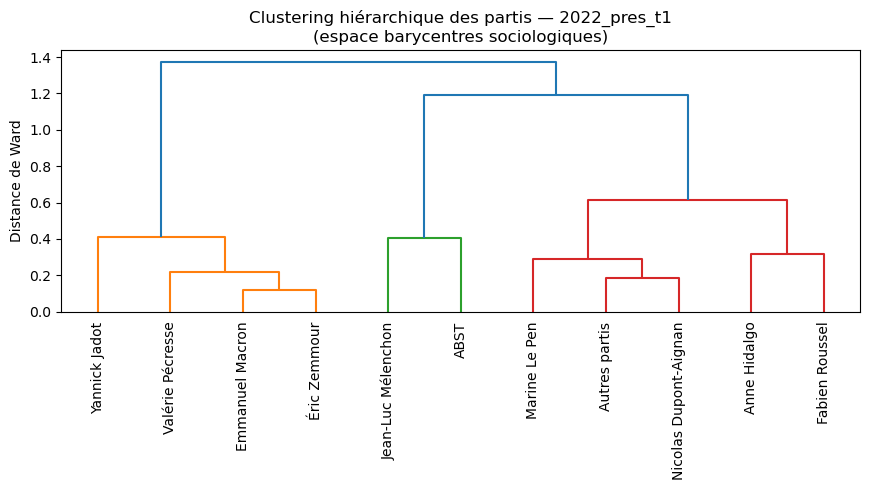

In [88]:
import matplotlib
import matplotlib.pyplot as plt

bary_clean = bary_df.dropna().astype(float)
if len(bary_clean) >= 2:
    Z_bary = linkage(bary_clean.values, method='ward')
    labels_bary = [party_label(p) for p in bary_clean.index]

    fig_dendro, ax = plt.subplots(figsize=(max(8, len(bary_clean) * 0.8), 5))
    dn = dendrogram(Z_bary, labels=labels_bary, ax=ax,
                    leaf_font_size=10, color_threshold=0.6 * max(Z_bary[:, 2]))
    ax.set_title(f'Clustering hiérarchique des partis — {ELEC_S2}\n(espace barycentres sociologiques)')
    ax.set_ylabel('Distance de Ward')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('Pas assez de partis avec barycentres complets.')


### 2.5 MDS et UMAP de l'espace partisan


In [89]:
# MDS sur la matrice de distance Wasserstein
n_parties = len(parties_s2)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_mds = mds.fit_transform(wass.astype(float).values)

# UMAP sur les barycentres sociologiques
bary_full = bary_df.fillna(0).astype(float)
if len(bary_full) >= 4:
    reducer = umap_lib.UMAP(n_components=2, n_neighbors=max(3, n_parties - 1),
                             min_dist=0.3, random_state=42)
    coords_umap = reducer.fit_transform(bary_full.values)
else:
    coords_umap = bary_full[SCORES_COMPOSITES[:2]].values  # fallback

# Figure côte à côte
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['MDS (distance Wasserstein)', 'UMAP (barycentres sociologiques)'])
for col_i, (coords, title) in enumerate([(coords_mds, 'MDS'), (coords_umap, 'UMAP')], 1):
    parties_for_coords = parties_s2 if col_i == 1 else list(bary_full.index)
    for j, party in enumerate(parties_for_coords):
        fig.add_trace(go.Scatter(
            x=[coords[j, 0]], y=[coords[j, 1]],
            mode='markers+text',
            text=[party_label(party)],
            textposition='top center',
            marker=dict(size=14, color=party_color(party),
                        line=dict(width=1.5, color='white')),
            showlegend=False,
            hovertemplate=f'{party_label(party)}<br>({coords[j,0]:.2f}, {coords[j,1]:.2f})<extra></extra>'
        ), row=1, col=col_i)

fig.update_layout(title=f'Espace partisan 2D — {ELEC_S2}', height=500, width=1000)
fig.show()


### 2.6 Network des partis

Nœuds = partis. Arêtes = corrélation |r| > seuil. Rouge = corrélation positive (même territoire), bleu = négative (concurrence).


In [90]:
THRESHOLD_NETWORK = 0.25  # seuil de corrélation pour une arête

G = nx.Graph()
for p in parties_s2:
    G.add_node(p)

edges_pos, edges_neg = [], []
for i, p1 in enumerate(parties_s2):
    for j, p2 in enumerate(parties_s2):
        if i < j:
            r = float(party_corr.loc[p1, p2])
            if abs(r) > THRESHOLD_NETWORK:
                G.add_edge(p1, p2, weight=r)
                if r > 0:
                    edges_pos.append((p1, p2, r))
                else:
                    edges_neg.append((p1, p2, r))

pos_net = nx.spring_layout(G, seed=42, weight='weight')

fig = go.Figure()

# Arêtes positives (rouge) et négatives (bleu)
for edge_list, col in [(edges_pos, 'rgba(239,68,68,0.6)'), (edges_neg, 'rgba(59,130,246,0.6)')]:
    for (p1, p2, r) in edge_list:
        x0, y0 = pos_net[p1]
        x1, y1 = pos_net[p2]
        fig.add_trace(go.Scatter(
            x=[x0, x1, None], y=[y0, y1, None],
            mode='lines',
            line=dict(width=abs(r) * 4, color=col),
            showlegend=False, hoverinfo='skip'
        ))

# Nœuds
for p in parties_s2:
    x, y = pos_net[p]
    fig.add_trace(go.Scatter(
        x=[x], y=[y],
        mode='markers+text',
        text=[party_label(p)], textposition='top center',
        marker=dict(size=18, color=party_color(p),
                    line=dict(width=1.5, color='white')),
        showlegend=False,
        hovertemplate=f'{party_label(p)}<extra></extra>'
    ))

fig.update_layout(
    title=f'Network des partis — {ELEC_S2} (|r| > {THRESHOLD_NETWORK})',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    width=700, height=600
)
fig.show()


### 2.7 Analyse Procrustes inter-élections

Mesure le déplacement de la structure partisane d'une élection à l'autre après rotation optimale.


In [91]:
ELEC_A = '2017_pres_t1'
ELEC_B = '2022_pres_t1'


def get_barycentre_matrix(elec_id, vars_list):
    """Retourne un DataFrame (partis canoniques × variables) de barycentres."""
    m, pts = get_elec_df(elec_id)
    rows = {}
    for p in pts:
        canon = PARTY_ALIAS.get(p, p)
        b = barycentre(m, p, vars_list)
        if not any(np.isnan(v) for v in b.values()):
            rows[canon] = b
    return pd.DataFrame(rows).T


bary_a = get_barycentre_matrix(ELEC_A, SCORES_COMPOSITES)
bary_b = get_barycentre_matrix(ELEC_B, SCORES_COMPOSITES)

common_parties = sorted(set(bary_a.index) & set(bary_b.index))
print(f'Partis communs ({ELEC_A} ↔ {ELEC_B}) : {common_parties}')

if len(common_parties) >= 3:
    A_mat = bary_a.loc[common_parties].astype(float).values
    B_mat = bary_b.loc[common_parties].astype(float).values

    A_std, B_std, disparity = scipy_procrustes(A_mat, B_mat)
    print(f'Disparité Procrustes : {disparity:.4f}  (0=identique, 1=max déplacement)')

    # Projeter en 2D pour visualiser
    pca2 = PCA(n_components=2)
    both_stacked = np.vstack([A_std, B_std])
    coords2d = pca2.fit_transform(both_stacked)
    A2d = coords2d[:len(common_parties)]
    B2d = coords2d[len(common_parties):]

    fig = go.Figure()
    for i, p in enumerate(common_parties):
        col = party_color(p)
        lbl = party_label(p)
        # Flèche A → B
        fig.add_annotation(
            x=B2d[i, 0], y=B2d[i, 1],
            ax=A2d[i, 0], ay=A2d[i, 1],
            xref='x', yref='y', axref='x', ayref='y',
            arrowhead=2, arrowwidth=2, arrowcolor=col
        )
        # Point A
        fig.add_trace(go.Scatter(
            x=[A2d[i, 0]], y=[A2d[i, 1]],
            mode='markers', marker=dict(size=10, color=col, opacity=0.5,
                                         symbol='circle-open', line=dict(width=2)),
            name=f'{lbl} ({ELEC_A})', showlegend=False
        ))
        # Point B
        fig.add_trace(go.Scatter(
            x=[B2d[i, 0]], y=[B2d[i, 1]],
            mode='markers+text', text=[lbl], textposition='top right',
            marker=dict(size=12, color=col),
            name=f'{lbl} ({ELEC_B})', showlegend=False
        ))

    fig.update_layout(
        title=f'Procrustes {ELEC_A} → {ELEC_B}  (disparité={disparity:.4f})',
        xaxis_title='PC1', yaxis_title='PC2',
        width=700, height=600
    )
    fig.show()
else:
    print('Pas assez de partis communs pour le Procrustes.')


Partis communs (2017_pres_t1 ↔ 2022_pres_t1) : ['ABST', 'AUTRE', 'DLF', 'ENS', 'LFI', 'LR', 'PS', 'RN']
Disparité Procrustes : 0.1932  (0=identique, 1=max déplacement)


---
## Section 3 — Report de voix

**Méthodes** :
- 3.1 RxC Ecological Inference (pyei)
- 3.2 Spatial Ecological Inference (libpysal)
- 3.3 Dirichlet-Multinomial bayésien (pymc)
- 3.4 Seemingly Unrelated Regressions (SUR)
- 3.5 Sankey agrégé
- 3.6 IRIS atypiques
- 3.7 Comparaisons inter-élections

> **Note** : toutes les méthodes bayésiennes (3.1, 3.3) utilisent un sous-échantillon de 3 000 IRIS
> pour rester computationnellement raisonnables. Augmenter `N_SAMPLE` si la machine le permet.


In [114]:
# ── Choix de la paire T1/T2 ───────────────────────────────────────────────────
ELEC_T1 = '2022_pres_t1'
ELEC_T2 = '2022_pres_t2'
N_SAMPLE = 3000   # nb IRIS pour MCMC (augmenter si besoin)

merged_t1, parties_t1 = get_elec_df(ELEC_T1, min_presence_frac=0.0)  # garder tous les partis
merged_t2, parties_t2 = get_elec_df(ELEC_T2, min_presence_frac=0.0)

merged_t1.drop(columns=['score_ABST'])
merged_t2.drop(columns=['score_ABST'])
parties_t1 = [p for p in parties_t1 if p != 'ABST']
parties_t2 = [p for p in parties_t2 if p != 'ABST']
              
# Fusion T1 + T2 sur les mêmes IRIS
t1_cols = ['IRIS', 'exprimes'] + [f'score_{p}' for p in parties_t1]
t2_cols = ['IRIS', 'exprimes'] + [f'score_{p}' for p in parties_t2]

t1_sub = elections_raw[ELEC_T1].rename(columns={'CODE_IRIS': 'IRIS'})[t1_cols]
t2_sub = elections_raw[ELEC_T2].rename(columns={'CODE_IRIS': 'IRIS'})[[c for c in t2_cols if c in elections_raw[ELEC_T2].rename(columns={'CODE_IRIS':'IRIS'}).columns]]

both = t1_sub.merge(t2_sub, on='IRIS', suffixes=('_t1', '_t2')).dropna()
both = both.merge(socio[['IRIS', 'pop_totale', 'segment']], on='IRIS', how='left')

print(f'IRIS avec T1+T2 : {len(both)}')
print(f'Partis T1 : {parties_t1}')
print(f'Partis T2 : {parties_t2}')


IRIS avec T1+T2 : 49097
Partis T1 : ['AUTRE', 'DUPONT_AIGNAN', 'HIDALGO', 'JADOT', 'LE_PEN', 'MACRON', 'MELENCHON', 'PECRESSE', 'ROUSSEL', 'ZEMMOUR']
Partis T2 : ['LE_PEN', 'MACRON']


### 3.1 RxC Ecological Inference (pyei)

Estimation de la matrice de flux T1→T2 via le modèle multinomial-Dirichlet.


In [121]:
import pyei
from pyei.r_by_c import RowByColumnEI

K_T1 = 4   # top K partis T1 + categorie AUTRES
K_T2 = 3   # top K partis T2 + categorie ABST

# Sous-echantillonnage stratifie par segment
rng = np.random.default_rng(42)
if 'segment' in both.columns and both['segment'].notna().any():
    sample_idx = both.groupby('segment', observed=True).apply(
        lambda g: g.sample(min(len(g), N_SAMPLE // 3), random_state=42)
    ).index.get_level_values(1)
    both_sample = both.loc[sample_idx].reset_index(drop=True)
else:
    both_sample = both.sample(min(N_SAMPLE, len(both)), random_state=42).reset_index(drop=True)

# Selectionner top K partis par score moyen
t1_score_cols = [f'score_{p}_t1' for p in parties_t1 if f'score_{p}_t1' in both_sample.columns]
t2_score_cols = [f'score_{p}_t2' for p in parties_t2 if f'score_{p}_t2' in both_sample.columns]

top_t1_cols = both_sample[t1_score_cols].mean().sort_values(ascending=False).head(K_T1).index.tolist()
top_t2_cols = both_sample[t2_score_cols].mean().sort_values(ascending=False).head(K_T2).index.tolist()

top_t1_names = [c.replace('score_', '').replace('_t1', '') for c in top_t1_cols]
top_t2_names = [c.replace('score_', '').replace('_t2', '') for c in top_t2_cols]

# Matrices T1 (% exprimes -> fraction 0-1)
mat_t1 = both_sample[top_t1_cols].fillna(0).values / 100.0   # (N, K_T1)
# Categorie residuelle AUTRES = reste des exprimes T1
autres_t1 = np.clip(1.0 - mat_t1.sum(axis=1, keepdims=True), 0, 1)
mat_t1_full = np.hstack([mat_t1, autres_t1])                  # (N, K_T1+1)
group_names = top_t1_names + ['AUTRES']

# Matrices T2 : scores T2 sont % des exprimes_T2 -> convertir en fraction des exprimes_T1
# car certains electeurs T1 peuvent s'abstenir au T2
exp_t1 = both_sample['exprimes_t1'].fillna(100).values.clip(1)
exp_t2 = np.where(np.isnan(both_sample['exprimes_t2'].values), exp_t1, both_sample['exprimes_t2'].values).clip(0)
scale_t2 = np.clip(exp_t2 / exp_t1, 0, 1)   # fraction T1 qui a vote au T2

mat_t2_base = both_sample[top_t2_cols].fillna(0).values / 100.0   # fraction des exprimes_T2
mat_t2 = mat_t2_base * scale_t2[:, None]                          # fraction des exprimes_T1

# ABST = fraction electeurs T1 qui n'ont pas vote au T2 (+ reste non modelise)
abst_col = np.clip(1.0 - mat_t2.sum(axis=1), 0, 1)
mat_t2_full = np.hstack([mat_t2, abst_col[:, None]])              # (N, K_T2+1)
cand_names = top_t2_names + ['ABST']

# Clip epsilon pour eliminer les zeros exacts (log(0) = -inf dans la vraisemblance multinomiale)
EPS = 1e-4
mat_t1_full = np.clip(mat_t1_full, EPS, 1)
mat_t2_full = np.clip(mat_t2_full, EPS, 1)
# Renormaliser exactement a 1
mat_t1_full /= mat_t1_full.sum(axis=1, keepdims=True)
mat_t2_full /= mat_t2_full.sum(axis=1, keepdims=True)

# pyei attend (nb_groupes x nb_iris) -> transposer
group_fracs = mat_t1_full.T
votes_fracs = mat_t2_full.T
precinct_pop = exp_t1.astype(int).clip(1)

print(f"Taille de l'echantillon : {len(both_sample)}")
print(f"Groupes T1 : {group_names}  ->  shape {group_fracs.shape}")
print(f"Candidats T2 : {cand_names}  ->  shape {votes_fracs.shape}")
print(f"Sommes group_fracs : [{group_fracs.sum(axis=0).min():.6f}, {group_fracs.sum(axis=0).max():.6f}]")
print(f"Sommes votes_fracs : [{votes_fracs.sum(axis=0).min():.6f}, {votes_fracs.sum(axis=0).max():.6f}]")

print('\nLancement MCMC (peut prendre quelques minutes)...')
ei_model = RowByColumnEI(model_name='multinomial-dirichlet')
ei_model.fit(
    group_fractions=group_fracs,
    votes_fractions=votes_fracs,
    precinct_pops=precinct_pop,
    demographic_group_names=group_names,
    candidate_names=cand_names,
    tune=500, draws=500, target_accept=0.9
)
print('MCMC termine.')

Taille de l'echantillon : 3000
Groupes T1 : ['LE_PEN', 'MACRON', 'AUTRES']  ->  shape (3, 3000)
Candidats T2 : ['MACRON', 'LE_PEN', 'ABST']  ->  shape (3, 3000)
Sommes group_fracs : [1.000000, 1.000000]
Sommes votes_fracs : [1.000000, 1.000000]

Lancement MCMC (peut prendre quelques minutes)...
Running ['LE_PEN', 'MACRON', 'AUTRES'] x ['MACRON', 'LE_PEN', 'ABST'] EI
r = 3 rows (demographic groups)
c = 3 columns (candidates or voting outcomes)
number of precincts = 3000


SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'conc_params_log__': array([[2.96833552, 1.57913198, 2.7484247 ],
       [1.83428628, 1.24672727, 2.60120609],
       [2.89760137, 2.65058715, 1.27588512]]), 'b_simplex__': array([[[-0.07844181, -0.45117815],
        [ 0.31867914, -0.65178171],
        [ 0.91667688,  1.35412659]],

       [[ 0.20454004, -0.98872782],
        [-0.72126482, -0.50259938],
        [ 1.33589498, -0.25309702]],

       [[ 0.47988303, -1.74315669],
        [-0.13666088, -0.71637311],
        [-0.37306588,  0.11542426]],

       ...,

       [[ 0.40286669, -1.45231476],
        [-0.67065811, -1.30358517],
        [ 1.1097925 , -0.43615483]],

       [[ 0.01897196, -1.1426578 ],
        [-0.88131684, -0.71944011],
        [ 0.73786557,  0.67348327]],

       [[ 1.06749489, -0.12940727],
        [-0.75706464, -0.69330803],
        [ 0.55578213,  1.17780972]]], shape=(3000, 3, 2))}

Logp initial evaluation results:
{'conc_param

In [120]:
both_sample['exprimes_t2'].fillna(exp_t1)
exp_t1

TypeError: "value" parameter must be a scalar, dict or Series, but you passed a "ndarray"

In [122]:
# Matrice de flux estimee
try:
    flux_mean = ei_model.posterior_mean_t()
    flux_df = pd.DataFrame(flux_mean, index=group_names, columns=cand_names)
    print('Matrice de flux T1 -> T2 (fraction des electeurs T1) :')
    display(flux_df.round(3))
except Exception as e:
    print('posterior_mean_t non disponible :', e)
    print(ei_model.summary())

posterior_mean_t non disponible : 'RowByColumnEI' object has no attribute 'posterior_mean_t'


TypeError: 'NoneType' object is not subscriptable

### 3.2 Spatial Ecological Inference

Même modèle que 3.1 mais avec lissage par voisinage (IRIS géographiquement proches ont des comportements similaires).

> **Note** : les données ne contiennent pas de coordonnées géographiques des IRIS.
> On utilise ici les coordonnées UMAP (espace socio) comme proxy de voisinage.
> Pour une analyse véritablement spatiale, substituer `umap_x`/`umap_y` par les coordonnées Lambert 93.


In [123]:
import libpysal
from libpysal.weights import KNN

# Utiliser umap_x/umap_y comme coordonnées de voisinage (proxy socio-spatial)
both_sample_socio = both_sample.merge(
    socio[['IRIS', 'umap_x', 'umap_y']].dropna(), on='IRIS', how='inner'
)

if len(both_sample_socio) > 50 and 'umap_x' in both_sample_socio.columns:
    coords_sp = both_sample_socio[['umap_x', 'umap_y']].values
    knn_w = KNN.from_array(coords_sp, k=5)
    knn_w.transform = 'r'  # row-standardize

    # Lisser les scores T1 par voisinage
    s_t1_smooth = score_t1.copy()
    for col in score_t1.columns:
        v = both_sample_socio[f'score_{col}_t1'].fillna(0).values if f'score_{col}_t1' in both_sample_socio.columns else score_t1[col].values
        sm = np.zeros_like(v, dtype=float)
        for i, neighbors in knn_w.neighbors.items():
            weights = list(knn_w.weights[i])
            sm[i] = v[i] * 0.7 + sum(v[j] * w for j, w in zip(neighbors, weights)) * 0.3
        s_t1_smooth[col] = sm

    print(f'Lissage spatial appliqué sur {len(both_sample_socio)} IRIS (voisinage k=5, espace UMAP socio).')
    print('Pour ré-estimer le modèle RxC avec les scores lissés, passer s_t1_smooth au lieu de score_t1 dans la cellule 3.1.')
else:
    print('Colonnes umap_x/umap_y absentes — lissage spatial impossible.')


Lissage spatial appliqué sur 3000 IRIS (voisinage k=5, espace UMAP socio).
Pour ré-estimer le modèle RxC avec les scores lissés, passer s_t1_smooth au lieu de score_t1 dans la cellule 3.1.


### 3.3 Dirichlet-Multinomial bayésien (pymc)


In [124]:
import pymc as pm
import arviz as az

# Modèle : pour chaque parti T2, son score est une combinaison linéaire des scores T1
# Prior : coefficients de report >= 0 et somment à 1 (Dirichlet)

n_t1 = group_fracs.shape[0]
n_t2 = votes_fracs.shape[0]
n_iris = group_fracs.shape[1]

# Utiliser le même sous-échantillon que 3.1
X_t1 = group_fracs.T.astype(np.float32)   # (n_iris, n_t1)
Y_t2 = votes_fracs.T.astype(np.float32)   # (n_iris, n_t2)

with pm.Model() as dirichlet_model:
    # Pour chaque parti T1, les coefficients de report vers les partis T2 suivent une Dirichlet
    # alpha_k : concentration hyperparameter (prior faible = uniforme)
    alpha = pm.HalfNormal('alpha', sigma=2.0, shape=(n_t1, n_t2))

    # Flux[i, k] = fraction des électeurs du parti T1 i qui votent pour le parti T2 k
    flux = pm.Dirichlet('flux', a=alpha + 0.1, shape=(n_t1, n_t2))

    # Prédiction : score T2 attendu = somme_i(score_T1_i * flux_i)
    mu = pm.Deterministic('mu', pm.math.dot(X_t1, flux))   # (n_iris, n_t2)

    # Likelihood : Dirichlet-Multinomial pour les votes observés
    concentration = mu * 10 + 0.1  # concentration proportionnelle à la prédiction
    y_obs = pm.Dirichlet('y_obs', a=concentration, observed=Y_t2)

    print('Modèle construit. Lancement de l\'inférence variationelle (ADVI, plus rapide que NUTS)...')
    approx = pm.fit(n=10000, method='advi', progressbar=True)
    trace_dirichlet = approx.sample(500)

print('Terminé.')
print(az.summary(trace_dirichlet, var_names=['flux']))


Modèle construit. Lancement de l'inférence variationelle (ADVI, plus rapide que NUTS)...


Output()

Interrupted at 14 [0%]: Average Loss = 1,935.2
arviz - WARNING - Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)


Terminé.
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
flux[0, 0]  0.335  0.189   0.026    0.667      0.009    0.006     428.0   
flux[0, 1]  0.310  0.193   0.021    0.660      0.009    0.005     456.0   
flux[0, 2]  0.355  0.251   0.006    0.811      0.012    0.007     435.0   
flux[1, 0]  0.348  0.195   0.045    0.716      0.012    0.005     280.0   
flux[1, 1]  0.318  0.190   0.045    0.703      0.008    0.006     483.0   
flux[1, 2]  0.334  0.239   0.023    0.788      0.013    0.007     390.0   
flux[2, 0]  0.313  0.173   0.003    0.610      0.007    0.006     567.0   
flux[2, 1]  0.322  0.184   0.033    0.660      0.008    0.005     580.0   
flux[2, 2]  0.364  0.242   0.010    0.782      0.011    0.006     483.0   

            ess_tail  r_hat  
flux[0, 0]     369.0    NaN  
flux[0, 1]     547.0    NaN  
flux[0, 2]     375.0    NaN  
flux[1, 0]     471.0    NaN  
flux[1, 1]     364.0    NaN  
flux[1, 2]     410.0    NaN  
flux[2, 0]     325.0    NaN  


In [ ]:
# Matrice de flux postérieure : moyenne + intervalle crédible 94%
flux_post = trace_dirichlet.posterior['flux'].values  # (chains, draws, n_t1, n_t2)
flux_post_flat = flux_post.reshape(-1, n_t1, n_t2)

flux_mean_dir = flux_post_flat.mean(axis=0)
flux_lo = np.percentile(flux_post_flat, 3, axis=0)
flux_hi = np.percentile(flux_post_flat, 97, axis=0)

flux_dir_df = pd.DataFrame(flux_mean_dir,
                           index=parties_t1[:n_t1],
                           columns=parties_t2[:n_t2])
print('Matrice de flux Dirichlet-Multinomial (moyenne postérieure) :')
display(flux_dir_df.round(3))


### 3.4 Seemingly Unrelated Regressions (SUR)

Estimation jointe de toutes les équations de report — capture les corrélations entre résidus.


In [125]:
# OLS par parti T2 + matrice de corrélation des résidus (l'insight-clé de la SUR)
# La sandbox SUR de statsmodels est incompatible avec numpy récent.
# On utilise des OLS indépendants et on calcule la matrice de covariance des résidus.

X_sur = both_sample[[f'score_{p}_t1' for p in parties_t1
                     if f'score_{p}_t1' in both_sample.columns]].fillna(0).values
X_sur_const = sm.add_constant(X_sur)
w_sur = both_sample['exprimes_t1'].fillna(1).values

sur_party_t2 = [p for p in parties_t2 if f'score_{p}_t2' in both_sample.columns]
ols_results = {}
residuals_df = pd.DataFrame(index=both_sample.index)

for p in sur_party_t2:
    y_k = both_sample[f'score_{p}_t2'].fillna(0).values
    res = sm.WLS(y_k, X_sur_const, weights=w_sur).fit()
    ols_results[p] = res
    residuals_df[p] = res.resid

# Coefficients
ols_coef_df = pd.DataFrame(
    {p: ols_results[p].params for p in sur_party_t2},
    index=['const'] + [f'T1_{p}' for p in parties_t1
                       if f'score_{p}_t1' in both_sample.columns]
).T
print('Coefficients OLS WLS (score T2 ~ scores T1) :')
display(ols_coef_df.round(3))

# Matrice de corrélation des résidus : révèle les concurrences non capturées par le modèle
resid_corr = residuals_df.corr()
fig = go.Figure(go.Heatmap(
    z=resid_corr.values,
    x=[party_label(p) for p in resid_corr.columns],
    y=[party_label(p) for p in resid_corr.index],
    colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title='r résidus'),
    hovertemplate='%{x} × %{y} : %{z:.3f}<extra></extra>'
))
fig.update_layout(
    title=f'Corrélation des résidus OLS — {ELEC_T1}→{ELEC_T2}<br>'
          'Résidu+ et résidu- d'un même IRIS pour 2 partis => compétition non capturée',
    width=600, height=600
)
fig.show()


SyntaxError: unterminated string literal (detected at line 41) (720160055.py, line 41)

### 3.5 Sankey agrégé T1 → T2

Flux estimés par le modèle RxC (pyei) ou SUR selon disponibilité.


In [98]:
# Utiliser la matrice de flux disponible (RxC si disponible, sinon SUR)
try:
    flux_matrix = flux_df.values  # pyei
    flux_row_labels = list(flux_df.index)
    flux_col_labels = list(flux_df.columns)
except NameError:
    # Utiliser SUR
    sur_cols = [c for c in sur_coefs.columns if c.startswith('T1_')]
    flux_matrix = sur_coefs[sur_cols].clip(0).values.T
    flux_matrix = flux_matrix / (flux_matrix.sum(axis=1, keepdims=True) + 1e-10)
    flux_row_labels = [c.replace('T1_', '') for c in sur_cols]
    flux_col_labels = list(sur_coefs.index)

# Voix absolues T1 pour pondérer les rubans
total_t1_votes = {p: both_sample[f'score_{p}_t1'].fillna(0).sum()
                  for p in flux_row_labels
                  if f'score_{p}_t1' in both_sample.columns}

n_src = len(flux_row_labels)
n_tgt = len(flux_col_labels)

# Construire les listes source/target/value pour Sankey
sources, targets, values, colors_sankey = [], [], [], []
for i, p1 in enumerate(flux_row_labels):
    votes_p1 = total_t1_votes.get(p1, 1)
    for j, p2 in enumerate(flux_col_labels):
        v = flux_matrix[i, j] * votes_p1
        if v > 0.01:
            sources.append(i)
            targets.append(n_src + j)
            values.append(float(v))
            colors_sankey.append(party_color(p1))

node_labels = [party_label(p) for p in flux_row_labels] + [party_label(p) for p in flux_col_labels]
node_colors = [party_color(p) for p in flux_row_labels] + [party_color(p) for p in flux_col_labels]

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=20,
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources, target=targets, value=values,
        color=[c.replace(')', ',0.35)').replace('rgb', 'rgba') if 'rgb' in c
               else c + '60' for c in colors_sankey]
    )
))
fig.update_layout(
    title=f'Report de voix {ELEC_T1} → {ELEC_T2}',
    width=800, height=500
)
fig.show()


NameError: name 'sur_coefs' is not defined

### 3.6 IRIS atypiques — résidus du modèle de report


In [126]:
# Résidus OLS par parti T2 : IRIS où le report observé s'écarte le plus du modèle moyen
# Utiliser l'ensemble complet (both) pour avoir assez d'IRIS

atypical_results = {}
for p in sur_party_t2[:3]:  # analyser les 3 premiers partis T2
    y_obs_full = both[f'score_{p}_t2'].fillna(0)
    X_full = both[[f'score_{q}_t1' for q in parties_t1
                   if f'score_{q}_t1' in both.columns]].fillna(0)
    X_full_c = sm.add_constant(X_full)

    res = sm.WLS(y_obs_full, X_full_c,
                 weights=both['exprimes_t1'].fillna(1)).fit()
    resid = res.resid

    threshold = resid.std() * 2
    atypical = both[np.abs(resid) > threshold].copy()
    atypical['resid'] = resid[np.abs(resid) > threshold]

    # Profil socio des IRIS atypiques vs moyenne
    atypical_socio = atypical.merge(socio[['IRIS'] + SCORES_COMPOSITES], on='IRIS', how='left')
    atypical_results[p] = atypical_socio
    print(f'{party_label(p)} : {len(atypical)} IRIS atypiques (|résidu| > 2σ)')


# Visualisation : résidus vs variables socio pour le premier parti
p_display = sur_party_t2[0]
at = atypical_results[p_display]

if 'score_domination' in at.columns and 'resid' in at.columns:
    fig = px.scatter(
        at, x='score_domination', y='resid',
        color='resid',
        color_continuous_scale='RdBu', color_continuous_midpoint=0,
        hover_data=['IRIS'],
        title=f'IRIS atypiques — report vers {party_label(p_display)}<br>résidu > 2σ vs score_domination',
        labels={'score_domination': 'Score domination (socio)', 'resid': 'Résidu du report estimé'}
    )
    fig.show()


NameError: name 'sur_party_t2' is not defined

### 3.7 Comparaisons inter-élections

Stabilité du vote territorial d'une élection à l'autre.


In [127]:
# Groupes d'élections comparables
ELECTION_SERIES = {
    'Présidentielles': ['2012_pres_t1', '2017_pres_t1', '2022_pres_t1'],
    'Législatives T1':  ['2012_legi_t1', '2017_legi_t1', '2022_legi_t1', '2024_legi_t1'],
    'Européennes':      ['2014_euro_t1', '2019_euro_t1', '2024_euro_t1'],
}


def scores_canonical(elec_id, min_pres=0.0):
    """Retourne un DataFrame IRIS × partis canoniques pour une élection."""
    df = elections_raw[elec_id].rename(columns={'CODE_IRIS': 'IRIS'})
    parties = get_parties(elec_id)
    out = df[['IRIS']].copy()
    for p in parties:
        canon = PARTY_ALIAS.get(p, p)
        sc = f'score_{p}'
        if sc in df.columns:
            if canon in out.columns:
                out[canon] = out[canon].fillna(0) + df[sc].fillna(0)
            else:
                out[canon] = df[sc].fillna(0)
    return out.set_index('IRIS')


for serie_name, elec_list in ELECTION_SERIES.items():
    print(f'\n{serie_name}')
    dfs = {e: scores_canonical(e) for e in elec_list if e in elections_raw}

    # Trouver les partis canoniques présents dans toutes les élections de la série
    all_parties_in_serie = sorted(set.intersection(*[set(d.columns) for d in dfs.values()]))
    all_parties_in_serie = [p for p in all_parties_in_serie
                             if all((dfs[e][p] > 1).mean() > 0.1 for e in dfs)]

    if not all_parties_in_serie:
        print('  Aucun parti commun avec présence suffisante.')
        continue

    print(f'  Partis communs : {all_parties_in_serie}')

    # Corrélation des scores IRIS entre deux scrutins consécutifs
    for i in range(len(elec_list) - 1):
        e1, e2 = elec_list[i], elec_list[i + 1]
        if e1 not in dfs or e2 not in dfs:
            continue
        common_iris = dfs[e1].index.intersection(dfs[e2].index)
        for p in all_parties_in_serie:
            if p not in dfs[e1].columns or p not in dfs[e2].columns:
                continue
            r = np.corrcoef(dfs[e1].loc[common_iris, p], dfs[e2].loc[common_iris, p])[0, 1]
            print(f'  {e1} → {e2} | {party_label(p):30s} : r={r:.3f}')



Présidentielles
  Partis communs : ['ABST', 'AUTRE', 'DLF', 'LFI', 'LR', 'PS', 'RN']
  2012_pres_t1 → 2017_pres_t1 | ABST                           : r=0.819
  2012_pres_t1 → 2017_pres_t1 | Autres partis                  : r=0.226
  2012_pres_t1 → 2017_pres_t1 | Debout la France               : r=0.362
  2012_pres_t1 → 2017_pres_t1 | La France Insoumise            : r=0.725
  2012_pres_t1 → 2017_pres_t1 | Les Républicains               : r=0.830
  2012_pres_t1 → 2017_pres_t1 | Parti Socialiste               : r=0.556
  2012_pres_t1 → 2017_pres_t1 | Rassemblement National         : r=0.853
  2017_pres_t1 → 2022_pres_t1 | ABST                           : r=0.856
  2017_pres_t1 → 2022_pres_t1 | Autres partis                  : r=0.641
  2017_pres_t1 → 2022_pres_t1 | Debout la France               : r=0.384
  2017_pres_t1 → 2022_pres_t1 | La France Insoumise            : r=0.806
  2017_pres_t1 → 2022_pres_t1 | Les Républicains               : r=0.648
  2017_pres_t1 → 2022_pres_t1 | Parti 

In [128]:
# IRIS "bascule" : variation > 2σ entre deux scrutins pour un parti donné
PARTY_BASCULE   = 'RN'
ELEC_BASCULE_A  = '2019_euro_t1'
ELEC_BASCULE_B  = '2024_euro_t1'

if ELEC_BASCULE_A in elections_raw and ELEC_BASCULE_B in elections_raw:
    sc_a = scores_canonical(ELEC_BASCULE_A)
    sc_b = scores_canonical(ELEC_BASCULE_B)

    if PARTY_BASCULE in sc_a.columns and PARTY_BASCULE in sc_b.columns:
        common = sc_a.index.intersection(sc_b.index)
        delta = sc_b.loc[common, PARTY_BASCULE] - sc_a.loc[common, PARTY_BASCULE]
        delta.name = 'delta'

        mu_d, sig_d = delta.mean(), delta.std()
        bascule = delta[(delta > mu_d + 2 * sig_d) | (delta < mu_d - 2 * sig_d)]

        bascule_socio = pd.DataFrame({'IRIS': bascule.index, 'delta': bascule.values})
        bascule_socio = bascule_socio.merge(socio[['IRIS'] + SCORES_COMPOSITES[:6]], on='IRIS', how='left')

        print(f'{len(bascule)} IRIS bascule {PARTY_BASCULE} ({ELEC_BASCULE_A} → {ELEC_BASCULE_B})')
        print(f'  Δ moyen général : {mu_d:+.2f} pts  |  σ : {sig_d:.2f} pts')

        # Profil socio : bascule haussière vs baissière
        bascule_up   = bascule_socio[bascule_socio['delta'] > mu_d + 2 * sig_d]
        bascule_down = bascule_socio[bascule_socio['delta'] < mu_d - 2 * sig_d]

        profil = pd.DataFrame({
            'IRIS bascule +': bascule_up[SCORES_COMPOSITES[:6]].mean(),
            'IRIS bascule −': bascule_down[SCORES_COMPOSITES[:6]].mean(),
            'Tous IRIS':      socio[SCORES_COMPOSITES[:6]].mean()
        })
        print(profil.round(2))

        # Histogram des deltas
        fig = px.histogram(
            delta.reset_index(name='delta'), x='delta', nbins=80,
            title=f'Distribution des variations {PARTY_BASCULE} — {ELEC_BASCULE_A} → {ELEC_BASCULE_B}',
            labels={'delta': 'Variation du score (pts)'},
            color_discrete_sequence=[party_color(PARTY_BASCULE)]
        )
        fig.add_vline(x=mu_d + 2*sig_d, line_dash='dash', line_color='red',
                      annotation_text='+2σ')
        fig.add_vline(x=mu_d - 2*sig_d, line_dash='dash', line_color='blue',
                      annotation_text='−2σ')
        fig.show()


2465 IRIS bascule RN (2019_euro_t1 → 2024_euro_t1)
  Δ moyen général : +8.80 pts  |  σ : 6.96 pts
                    IRIS bascule +  IRIS bascule −  Tous IRIS
score_domination             -1.23           -2.02      -0.49
score_exploitation            0.52           -0.40       0.26
score_cap_eco                 0.82           -0.79       0.34
score_cap_cult               -1.78           -1.71      -0.69
score_precarite              -0.57            1.23      -0.19
score_rentier                 0.87            0.67       0.53
